In [10]:
# loading the data from the Canada Open Data catalog

In [11]:
import json
import pandas as pd
import os
import re 
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# Each line contains valid JSON, but as a whole, it is not a valid JSON value as there is no top-level list or object definition. 
# A .jsonl file has one JSON object per line (unlike a single large JSON file).

In [13]:
# Loading the JSONL File
data_path = "D:/Harshita Ajmani/Code_harshu/NLP/data/od-do-canada.jsonl"
print("Loading dataset")

records = []

with open(data_path, "rt", encoding="utf-8") as f:
    print(f)
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

Loading dataset
<_io.TextIOWrapper name='D:/Harshita Ajmani/Code_harshu/NLP/data/od-do-canada.jsonl' mode='rt' encoding='utf-8'>


In [15]:
print(f"Loaded {len(records):,} records")
#print(records[0])

Loaded 46,468 records


In [16]:
# The records we keeping
'''record = {
    "id"               → unique ID
    "title_translated" → bilingual dataset name
    "notes_translated" → bilingual description  
    "keywords"         → bilingual tags
    "subject"          → topic category
    "organization"     → publishing department }
    
    A user cares about:
    What is this dataset? → title
    What does it contain? → desc
    What topics does it cover? → keywords, subject
    Who published it? → org'''


'record = {\n    "id"               → unique ID\n    "title_translated" → bilingual dataset name\n    "notes_translated" → bilingual description  \n    "keywords"         → bilingual tags\n    "subject"          → topic category\n    "organization"     → publishing department }\n    \n    A user cares about:\n    What is this dataset? → title\n    What does it contain? → desc\n    What topics does it cover? → keywords, subject\n    Who published it? → org'

In [17]:
#Extracting fields with bilingual dicts and returns "" for aany misiing entries
def extract_field(record, field, language):
    value = record.get(field, {})
    if isinstance(value, dict):
        return value.get(language, "").strip() 
    return "" 

In [18]:
# Cleanoing text by removing urls and extra spaces
def clean_text(text):
    text = re.sub(r'\*\*\[.*?\]\(.*?\)\*\*', '', text)  
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)           
    text = re.sub(r'\s+', ' ', text)                   
    return text.strip()

In [19]:
#Getting useful fields and adding them to rows
rows = []

for r in records:
    title_en = extract_field(r, "title_translated", "en") or r.get("title", "")
    title_fr = extract_field(r, "title_translated", "fr") or r.get("title", "")
    desc_en  = clean_text(extract_field(r, "notes_translated", "en"))
    desc_fr  = clean_text(extract_field(r, "notes_translated", "fr"))

    rows.append({
        "id":       r.get("id", ""),
        "title_en": title_en,
        "title_fr": title_fr,
        "desc_en":  desc_en,
        "desc_fr":  desc_fr,
        "keywords_en": ", ".join(r.get("keywords", {}).get("en", [])) if isinstance(r.get("keywords"), dict) else "",
        "keywords_fr": ", ".join(r.get("keywords", {}).get("fr", [])) if isinstance(r.get("keywords"), dict) else "",
        "subject":  ", ".join(r.get("subject", [])) if isinstance(r.get("subject"), list) else "",
        "org":      r.get("organization", {}).get("title", "") if isinstance(r.get("organization"), dict) else "",
    })

In [20]:
#pandas dataframe
df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"Before cleaning: {len(df):,} records")

DataFrame shape: (46468, 9)
Before cleaning: 46,468 records


In [21]:
#cleaning the data by removing records with no description in both languages and filling missing descriptions with titles
df = df[~((df["desc_en"] == "") & (df["desc_fr"] == ""))]
df["desc_en"] = df.apply(lambda x: x["desc_en"] if x["desc_en"] else x["title_en"], axis=1)
df["desc_fr"] = df.apply(lambda x: x["desc_fr"] if x["desc_fr"] else x["title_fr"], axis=1)
df = df.reset_index(drop=True)

print(f"After cleaning: {len(df):,} records")

After cleaning: 46,468 records


In [22]:
#Understanding the dataset with some quick stats and a sample record
print(f"\n📈 Quick stats:")
print(f"  Total records                    : {len(df):,}")
print(f"  Records with English title       : {(df['title_en'] != '').sum():,}")
print(f"  Records with French title        : {(df['title_fr'] != '').sum():,}")
print(f"  Records with English description : {(df['desc_en'] != '').sum():,}")
print(f"  Records with French description  : {(df['desc_fr'] != '').sum():,}")
print(f"  Records with BOTH descriptions   : {((df['desc_en'] != '') & (df['desc_fr'] != '')).sum():,}")
print(f"  Records with English keywords    : {(df['keywords_en'] != '').sum():,}")
print(f"  Records with French keywords     : {(df['keywords_fr'] != '').sum():,}")
print(f"  Unique organizations             : {df['org'].nunique():,}")
print(f"  Unique subjects                  : {df['subject'].nunique():,}")

print(f"\n📝 Sample record:")
print(f"  ID           : {df.iloc[0]['id']}")
print(f"  Title EN     : {df.iloc[0]['title_en']}")
print(f"  Title FR     : {df.iloc[0]['title_fr']}")
print(f"  Desc EN      : {df.iloc[0]['desc_en'][:120]}...")
print(f"  Desc FR      : {df.iloc[0]['desc_fr'][:120]}...")
print(f"  Keywords EN  : {df.iloc[0]['keywords_en'][:120]}...")
print(f"  Keywords FR  : {df.iloc[0]['keywords_fr'][:120]}...")
print(f"  Subject      : {df.iloc[0]['subject']}")
print(f"  Organization : {df.iloc[0]['org']}")


📈 Quick stats:
  Total records                    : 46,468
  Records with English title       : 46,468
  Records with French title        : 46,468
  Records with English description : 46,468
  Records with French description  : 46,468
  Records with BOTH descriptions   : 46,468
  Records with English keywords    : 44,948
  Records with French keywords     : 36,566
  Unique organizations             : 132
  Unique subjects                  : 616

📝 Sample record:
  ID           : 000183ed-8864-42f0-ae43-c4313a860720
  Title EN     : Principal Mineral Areas, Producing Mines, and Oil and Gas Fields (900A)
  Title FR     : Principales régions minières, principales mines productrices, principaux champs de pétrole et de gaz (900A)
  Desc EN      : This dataset is produced and published annually by Natural Resources Canada. It contains a variety of statistics on Cana...
  Desc FR      : Ce jeu de données est produit et publié annuellement par Natural Resources Canada. Il contient une variété

FileNotFoundError: [Errno 2] No such file or directory: 'data/dataset_overview.png'

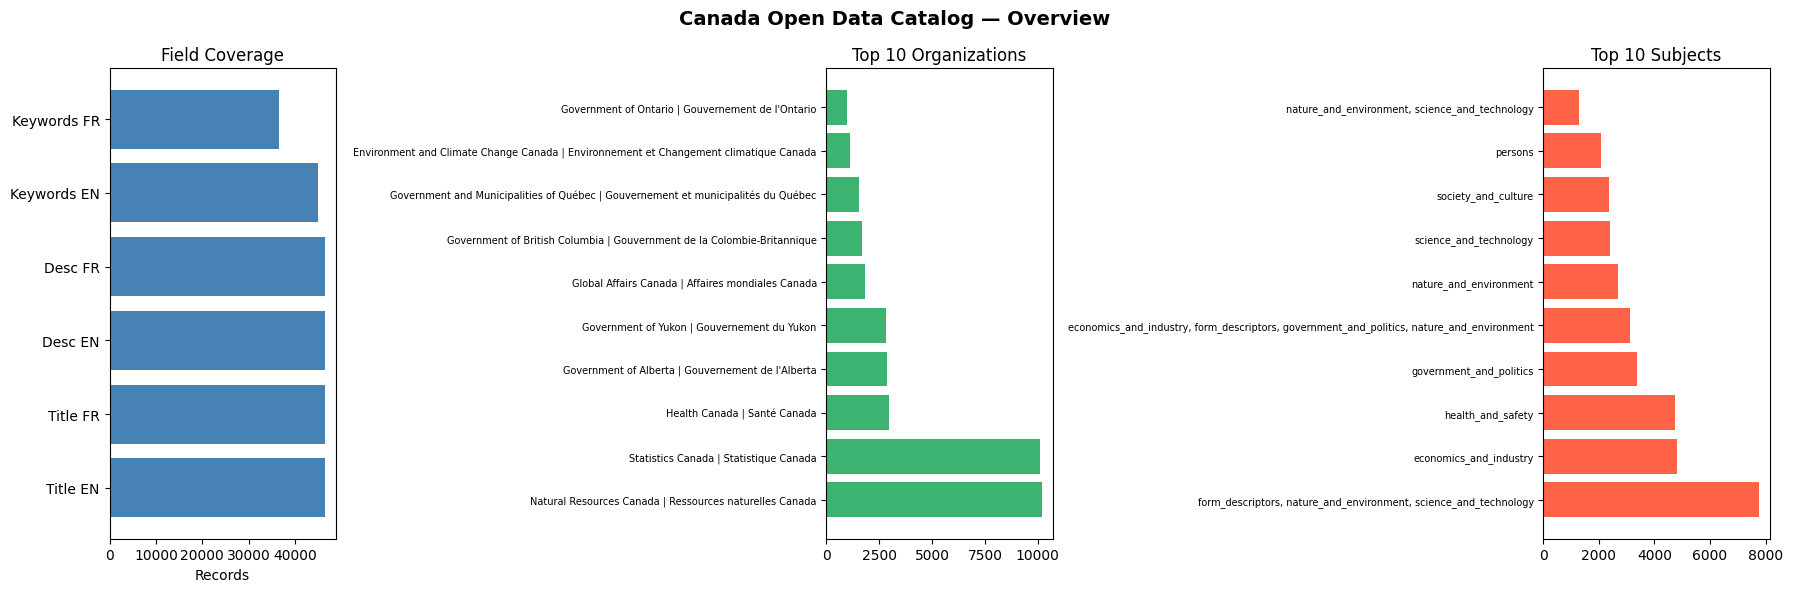

In [23]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Canada Open Data Catalog — Overview", fontsize=14, fontweight='bold')

# Plot 1 — Field Coverage
stats = {
    "Title EN":    (df['title_en'] != '').sum(),
    "Title FR":    (df['title_fr'] != '').sum(),
    "Desc EN":     (df['desc_en'] != '').sum(),
    "Desc FR":     (df['desc_fr'] != '').sum(),
    "Keywords EN": (df['keywords_en'] != '').sum(),
    "Keywords FR": (df['keywords_fr'] != '').sum(),
}
axes[0].barh(list(stats.keys()), list(stats.values()), color='steelblue')
axes[0].set_title("Field Coverage")
axes[0].set_xlabel("Records")

# Plot 2 — Top 10 Orgs
top_orgs = df['org'].value_counts().head(10)
axes[1].barh(top_orgs.index, top_orgs.values, color='mediumseagreen')
axes[1].set_title("Top 10 Organizations")
axes[1].tick_params(axis='y', labelsize=7)

# Plot 3 — Top 10 Subjects
top_subjects = df['subject'].value_counts().head(10)
axes[2].barh(top_subjects.index, top_subjects.values, color='tomato')
axes[2].set_title("Top 10 Subjects")
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig("data/dataset_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved to data/dataset_overview.png")

In [24]:
# Saving the cleaned dataset
save_path = "D:/Harshita Ajmani/Code_harshu/NLP/data/cleaned_data.csv"

os.makedirs(os.path.dirname(save_path), exist_ok=True)

if os.path.exists(save_path):
    os.remove(save_path)
    print("Old file removed")

df.to_csv(save_path, index=False)
print(f"Saved to {save_path}")

Old file removed
Saved to D:/Harshita Ajmani/Code_harshu/NLP/data/cleaned_data.csv
